In [2]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 

In [ ]:
''' 
This notebook performs data collection and analysis on the forex data. 
    
    1. Collect and preprocess financial time series data:
        Retrieve Forex price data using yfinance 
        Compute daily returns and log returns 

    2. Perform Exploratory Data analysis
        Visual Analysis
            Plot of Prices 
            Plot of Returns
            Histgram w theoretical normal
            QQplots 
            ACF and PACF plots

        Quantitative Analysis
            Returns distribution: Jarque-Bera test
            Autocorrelation Significance: Ljung-Box test
            Heteroskedasticity: ARCH LM test
'''

' \nThis notebook performs data collection and analysis on the forex data. \n\n    1. Collect and preprocess financial time series data:\n        Retrieve Forex price data using yfinance \n        Compute daily returns and log returns \n\n    2. Perform Exploratory Data analysis\n        Visual Analysis\n            Histgram w theoretical normal\n            QQplots \n            ACF and PACF plots\n\n        Quantitative Analysis\n            Returns distribution: Jarque-Bera test\n            Autocorrelation Significance: Ljung-Box test\n            Heteroskedasticity: ARCH LM test\n'

In [3]:
# Load FOREX data
# EUR/USD, BTC/USD and USD/CAD
tickers = ["EURUSD=X", "BTD-USD", "CAD=X"] # not forex data yet 
start, end = "2014-01-01", "2024-06-30" 

data = yf.download(tickers, start=start, end=end, progress=False)
prices = data["Close"].copy()
prices.dropna(inplace=True)

prices.set_index(prices.index, inplace=True)
prices.columns = tickers

# save data to csv
prices.to_csv("../data/prices.csv")

# check data
print(prices.info())
prices.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 421 entries, 2021-01-11 to 2022-08-22
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  421 non-null    float64
 1   BTD-USD   421 non-null    float64
 2   CAD=X     421 non-null    float64
dtypes: float64(3)
memory usage: 13.2 KB
None


,EURUSD=X,BTD-USD,CAD=X
Date,,,
2021-01-11,0.201892,1.27308,1.218621
2021-01-12,0.141996,1.27714,1.216070
2021-01-13,0.093772,1.27077,1.220889
2021-01-14,0.067057,1.26981,1.216249
2021-01-15,0.058177,1.26477,1.215126


In [4]:
# Daily returns :
returns = prices.pct_change().dropna()*100

# save returns to csv
returns.to_csv("../data/returns.csv")

# check returns
print(returns.info())
returns.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420 entries, 2021-01-12 to 2022-08-22
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  420 non-null    float64
 1   BTD-USD   420 non-null    float64
 2   CAD=X     420 non-null    float64
dtypes: float64(3)
memory usage: 13.1 KB
None


,EURUSD=X,BTD-USD,CAD=X
Date,,,
2021-01-12,-29.667350,0.318914,-0.209283
2021-01-13,-33.961517,-0.498776,0.396299
2021-01-14,-28.489317,-0.075544,-0.380079
2021-01-15,-13.242461,-0.396904,-0.092349
2021-01-18,-81.451433,0.925063,-0.684259


In [5]:
# Log returns :
log_returns = np.log(prices / prices.shift(1)).dropna()*100

# save log returns to csv
log_returns.to_csv("../data/log_returns.csv")

# check log returns
print(log_returns.info())
log_returns.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420 entries, 2021-01-12 to 2022-08-22
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  420 non-null    float64
 1   BTD-USD   420 non-null    float64
 2   CAD=X     420 non-null    float64
dtypes: float64(3)
memory usage: 13.1 KB
None


,EURUSD=X,BTD-USD,CAD=X
Date,,,
2021-01-12,-35.193406,0.318407,-0.209502
2021-01-13,-41.493254,-0.500024,0.395516
2021-01-14,-33.532334,-0.075573,-0.380803
2021-01-15,-14.205287,-0.397694,-0.092391
2021-01-18,-168.477767,0.920810,-0.686611


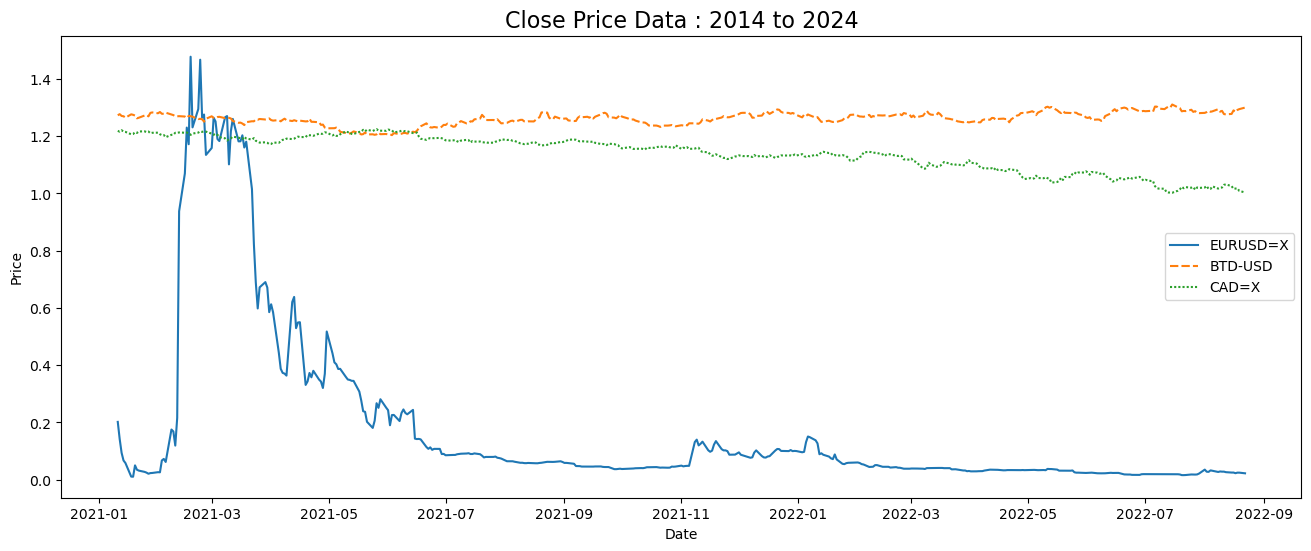

In [6]:
# Plot price data
plt.figure(figsize=(16, 6))

sns.lineplot(data=prices)

title = "Close Price Data"
plt.title(f"{title} : {start[:4]} to {end[:4]}", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# save plot
plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

plt.show()

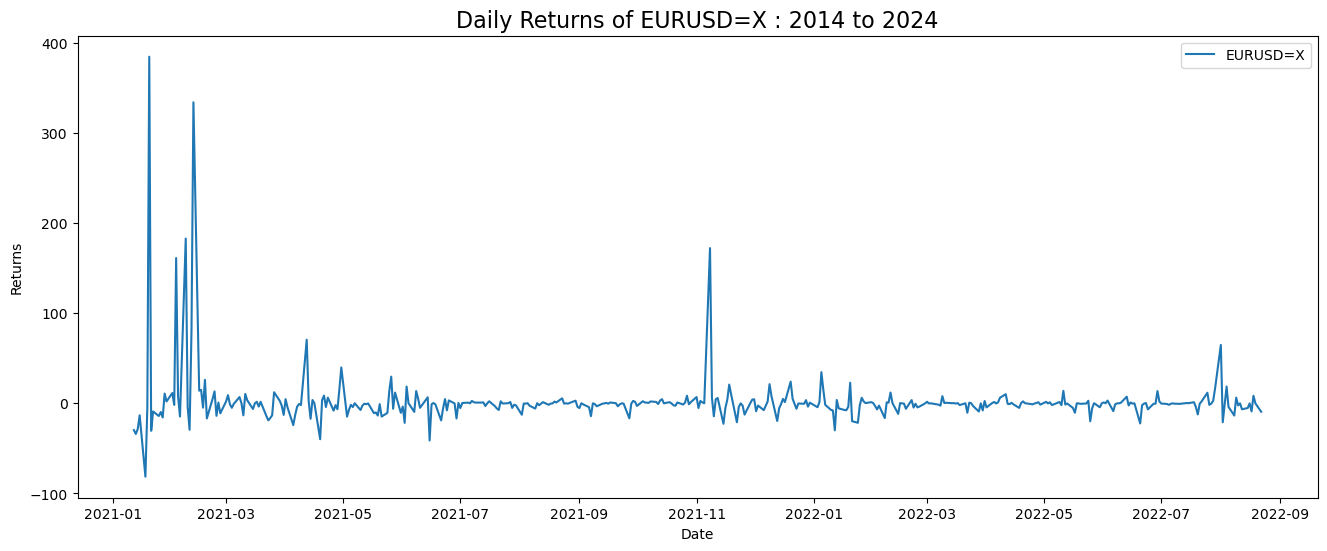

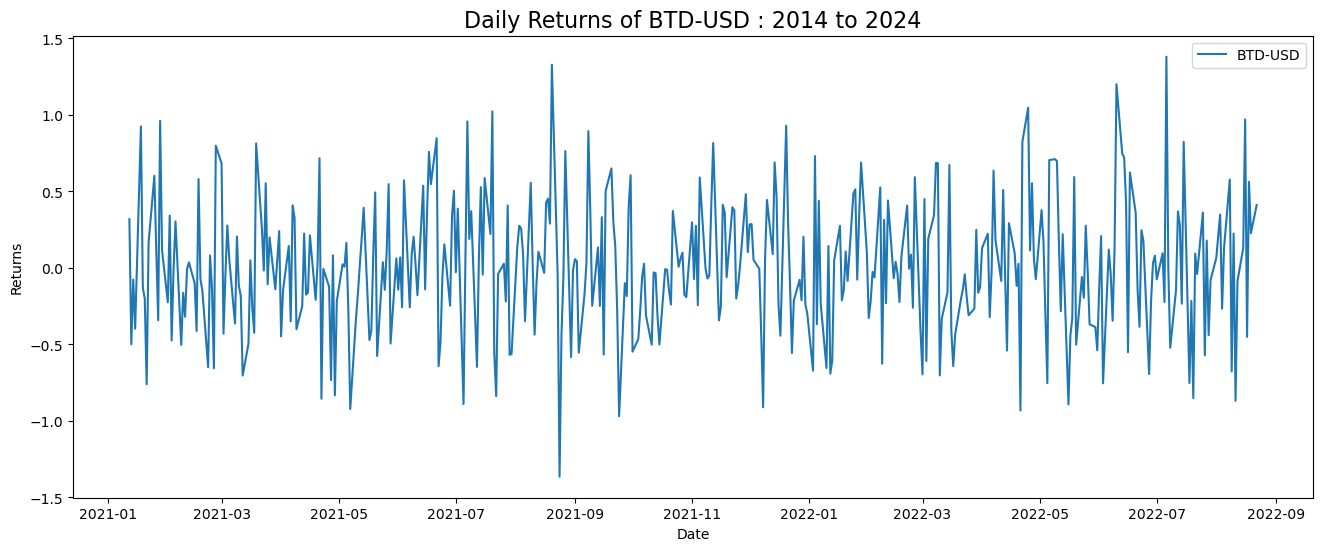

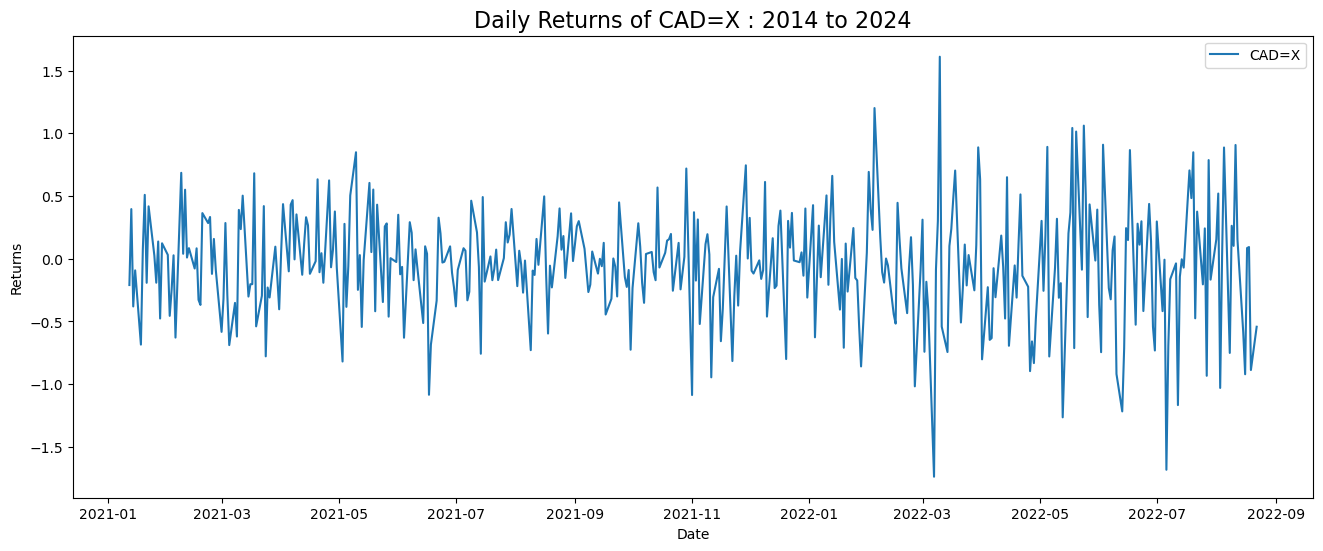

In [8]:
# Plot returns data
for ticker in tickers:
    plt.figure(figsize=(16, 6))

    sns.lineplot(data=returns[ticker], label=ticker)

    title = f"Daily Returns of {ticker}"
    plt.title(f"{title} : {start[:4]} to {end[:4]}", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    plt.legend()

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

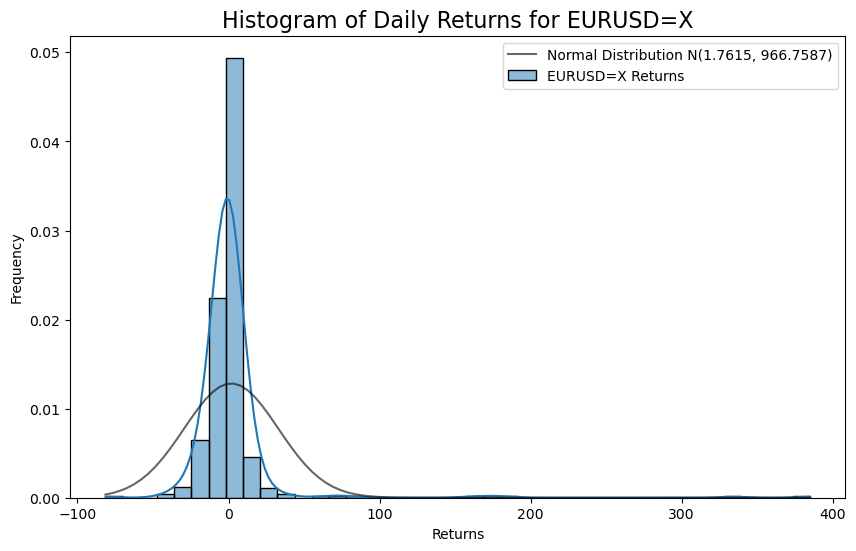

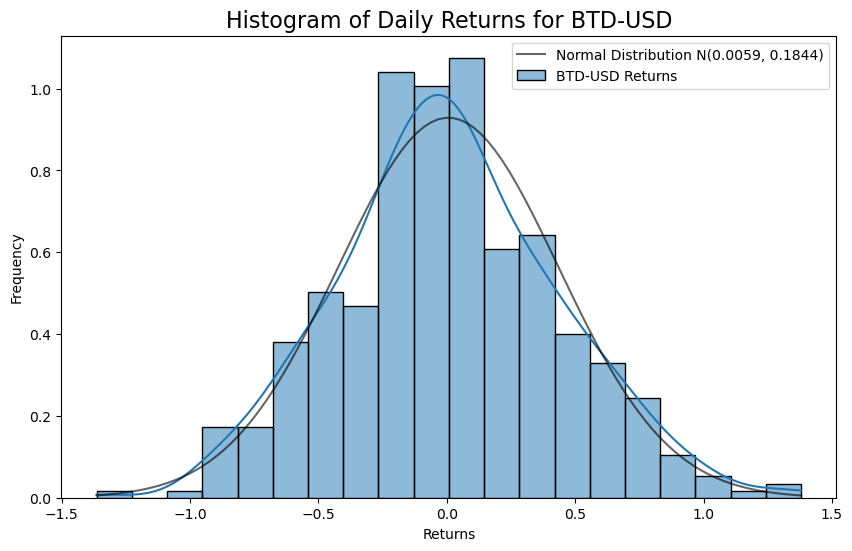

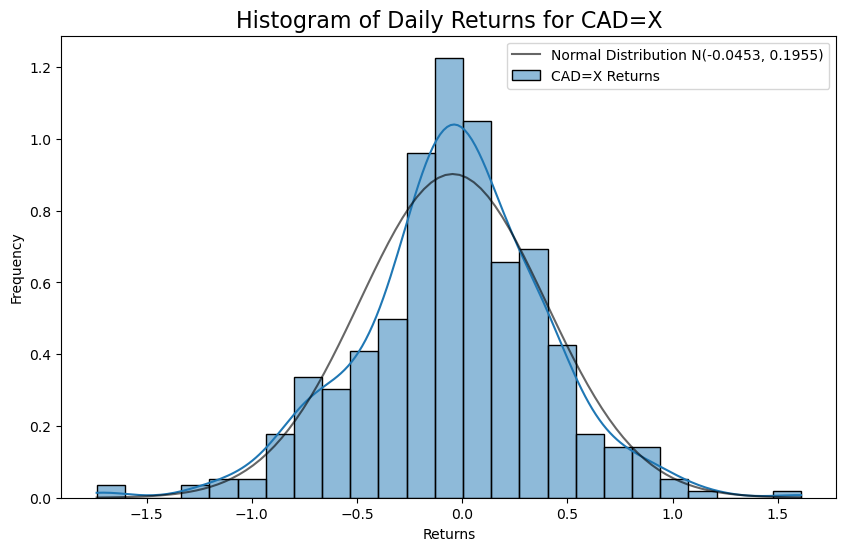

In [9]:
# Plot histogram of returns
for ticker in tickers:
    plt.figure(figsize=(10, 6))

    # Empirical distribution of returns
    sns.histplot(data=returns[ticker], 
        bins='auto', 
        kde=True,
        stat='density', 
        label=f'{ticker} Returns')

    # Theoretical normal distribution curve
    mean = returns[ticker].mean()
    std = returns[ticker].std()
    x = np.linspace(returns[ticker].min(), returns[ticker].max(), 100)
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    plt.plot(x, pdf, 
        alpha=0.6, 
        color='black', 
        label='Normal Distribution N({:.4f}, {:.4f})'.format(mean, std**2))

    title = f"Histogram of Daily Returns for {ticker}"
    plt.title(title, fontsize=16)
    plt.xlabel("Returns")
    plt.ylabel("Frequency")
    plt.legend()

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

<Figure size 1000x600 with 0 Axes>

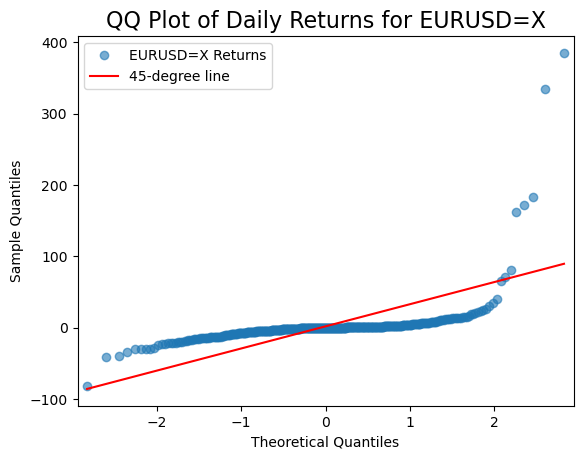

<Figure size 1000x600 with 0 Axes>

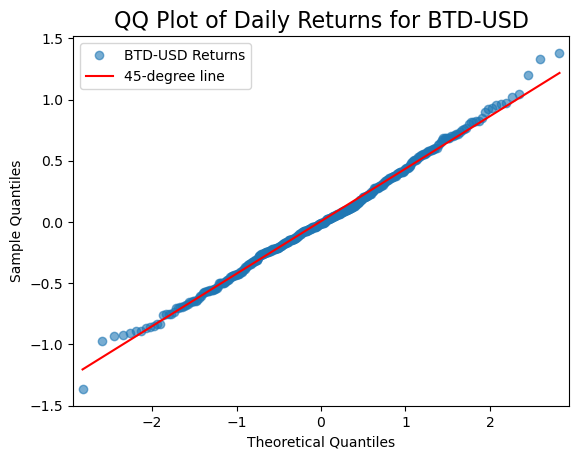

<Figure size 1000x600 with 0 Axes>

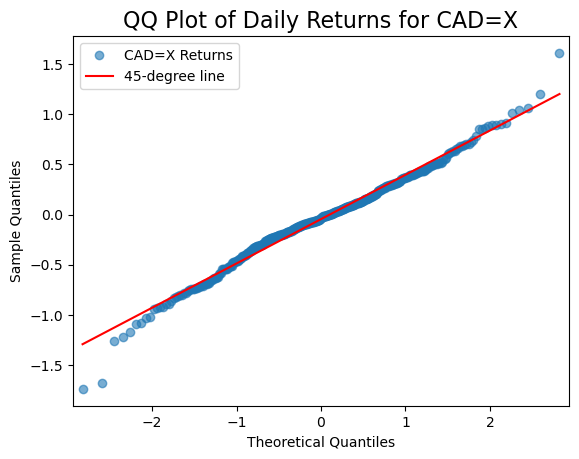

In [10]:
# QQ plots for ticker in tickers
for ticker in tickers:
    plt.figure(figsize=(10, 6))

    # QQ plot
    sm.qqplot(returns[ticker], line='s', alpha=0.6, color='blue')

    title = f"QQ Plot of Daily Returns for {ticker}"
    plt.title(title, fontsize=16)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.legend([f'{ticker} Returns', '45-degree line'])

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [11]:
# descriptive statistics
desc_stats = returns.describe()

skewness = returns.skew()
kurtosis = returns.kurtosis()

# add to descriptive statistics
desc_stats.loc["skew"] = skewness
desc_stats.loc["kurt"] = kurtosis
 
desc_stats

,EURUSD=X,BTD-USD,CAD=X
count,420.000000,420.000000,420.000000
mean,1.761460,0.005907,-0.045252
std,31.092743,0.429436,0.442147
min,-81.451433,-1.364419,-1.737753
25%,-4.234932,-0.257072,-0.274423
50%,-0.183439,-0.010388,-0.033213
75%,1.522514,0.281910,0.232053
max,384.933469,1.380541,1.611238
skew,8.622866,0.168425,-0.188561
kurt,91.567332,0.121057,1.076052


In [12]:
# Normality Analysis

# Jarque-Bera test for normality
# H0: Returns are normally distributed
# If JB is Large or p-value is small => reject null hypthesis of normality

normality_df = pd.DataFrame(index=["Skewness", "Kurtosis", "JB Statistic", "p-value", "H0 Rejection"], columns=tickers)

for ticker in tickers:
    skewness = returns[ticker].skew()
    kurtosis = returns[ticker].kurtosis()
    jb_stat, p_value = jarque_bera(returns[ticker])
    reject_null = p_value < 0.05

    normality_df[ticker] = [skewness, kurtosis, jb_stat, p_value, reject_null]

# save normality results to csv
# normality_df.to_csv("../results/normality_results.csv")

print("Normality Results: ")
normality_df

Normality Results: 


,EURUSD=X,BTD-USD,CAD=X
Skewness,8.622866,0.168425,-0.188561
Kurtosis,91.567332,0.121057,1.076052
JB Statistic,148391.283123,2.165821,21.729321
p-value,0.0,0.338609,0.000019
H0 Rejection,True,False,True


In [14]:
# Auto Correlation Analysis

# confidence level for autocorrelation significance
conf_level = 0.95 
t_critical = t.ppf((1 + conf_level) / 2, df=len(returns) - 2) 
acf_conf_interval = t_critical / np.sqrt(len(returns)) # confidence interval for autocorrelation
print(f"Autocorrelation significance threshold (95% confidence): ±{acf_conf_interval:.4f}")

# ACF and PACF values for ticker in tickers 
max_lags = 30
for ticker in tickers:
    acf_values = acf(returns[ticker], nlags=max_lags)
    pacf_values = pacf(returns[ticker], nlags=max_lags) 
    corr_df = pd.DataFrame({ 
        "ACF": acf_values,
        "PACF": pacf_values,
        "t-significance": [abs(val) > acf_conf_interval for val in acf_values],
    }) 

    print(f"Autocorrelation values for {ticker}:")
    print(corr_df)

Autocorrelation significance threshold (95% confidence): ±0.0959
Autocorrelation values for EURUSD=X:
         ACF      PACF  t-significance
0   1.000000  1.000000            True
1   0.046080  0.046190           False
2  -0.116157 -0.119101            True
3   0.099288  0.113384            True
4   0.136724  0.115025            True
5  -0.092449 -0.086262           False
6   0.021174  0.052143           False
7   0.157674  0.116921            True
8   0.018627  0.010979           False
9  -0.011277  0.033318           False
10  0.141182  0.114061            True
11  0.025414 -0.018602           False
12 -0.097424 -0.063091            True
13  0.157277  0.158462            True
14 -0.036647 -0.136028           False
15 -0.102057 -0.044636            True
16  0.040249  0.036296           False
17  0.302387  0.247829            True
18 -0.033123 -0.027856           False
19 -0.057745  0.010686           False
20 -0.015724 -0.138833           False
21 -0.012575 -0.060315           False
2

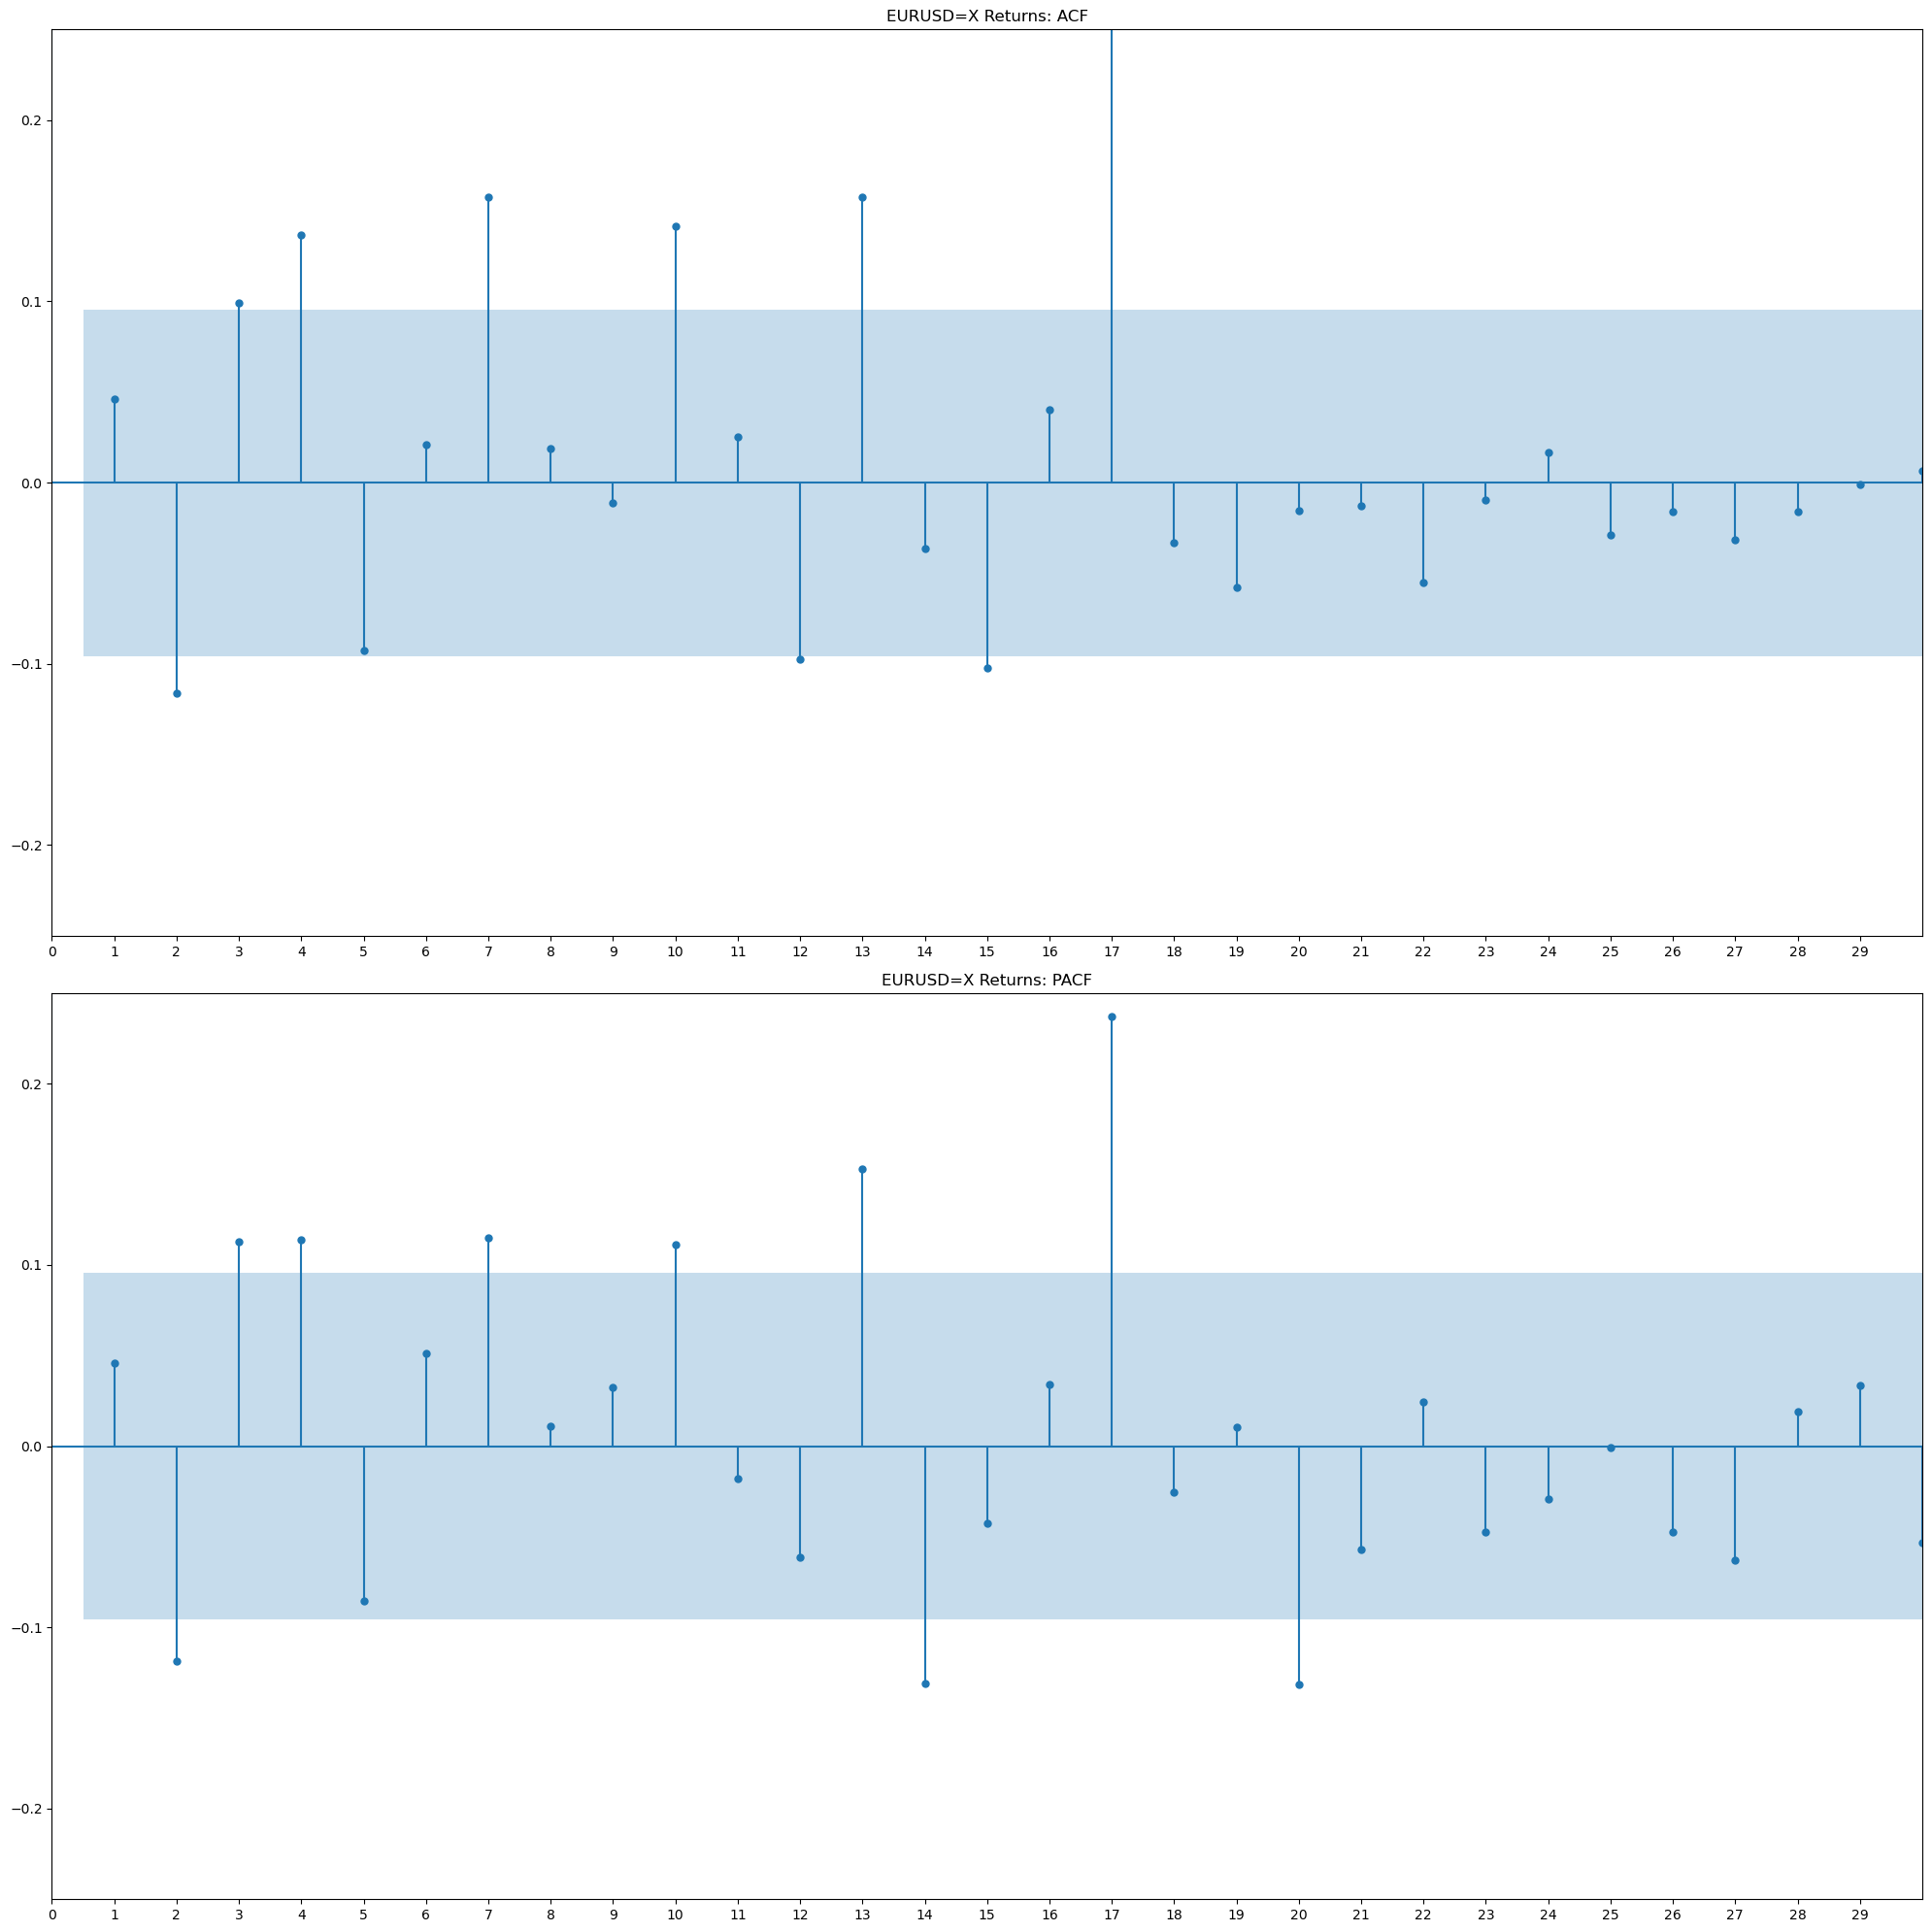

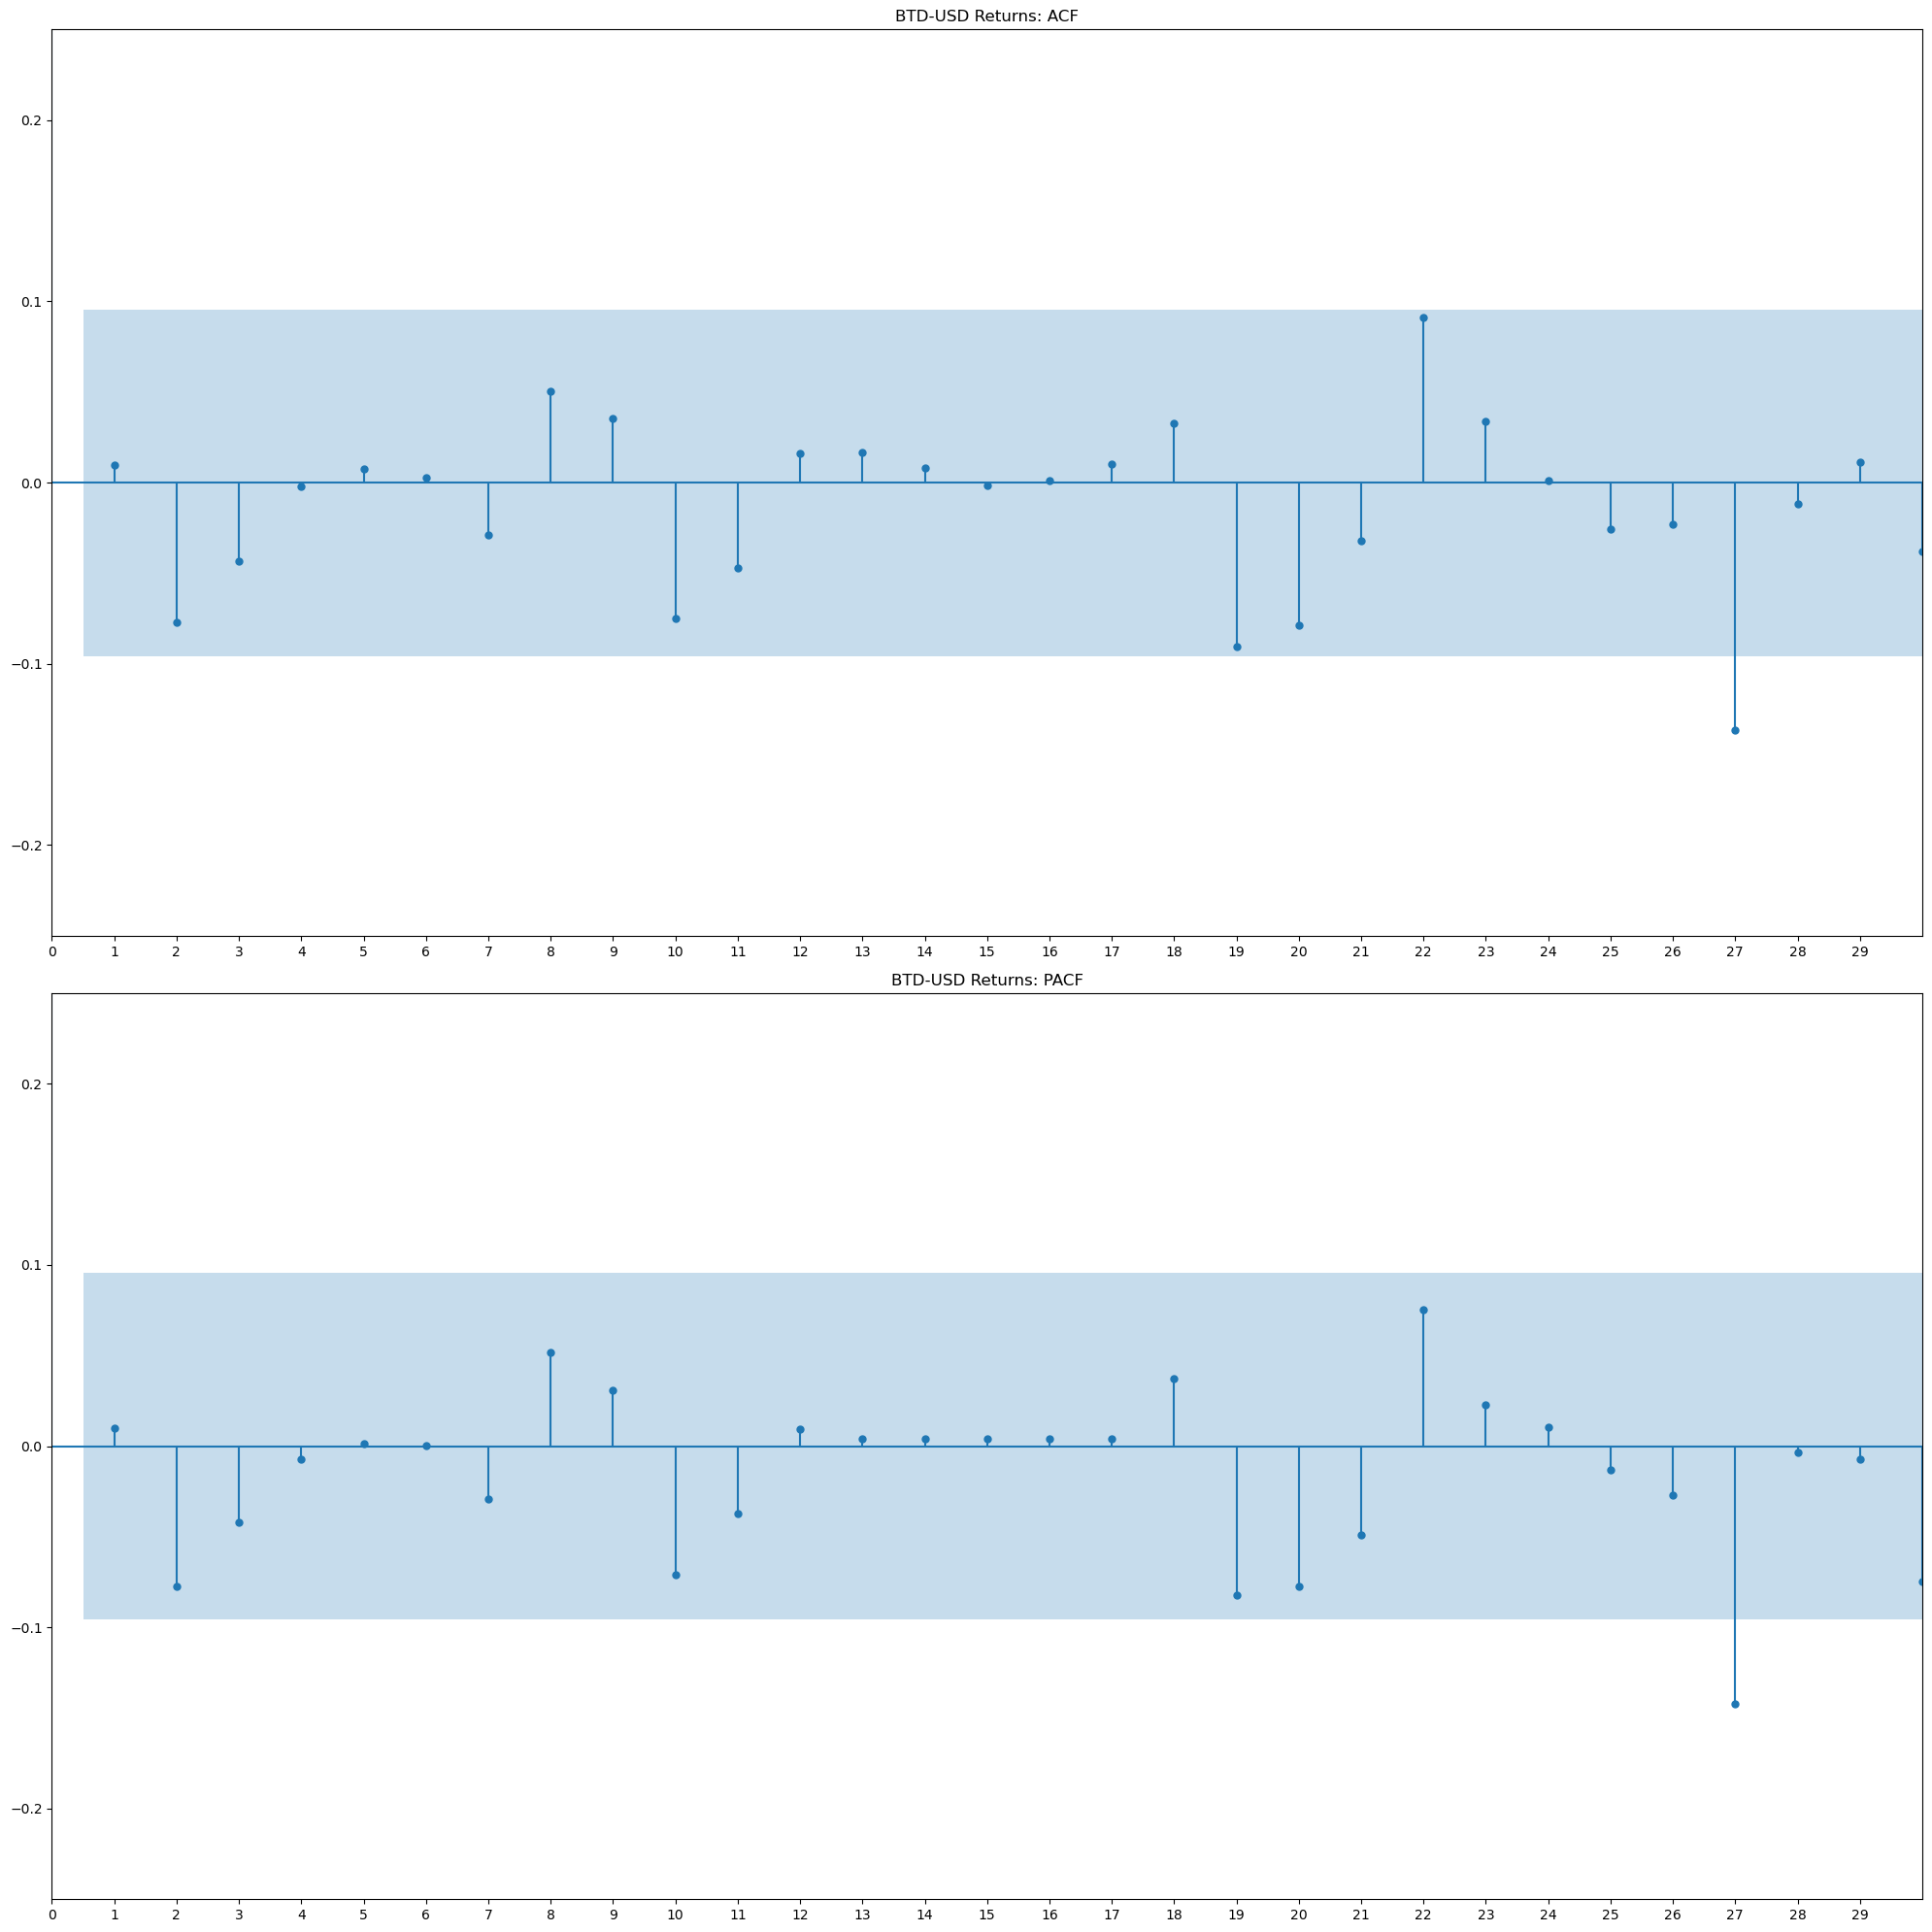

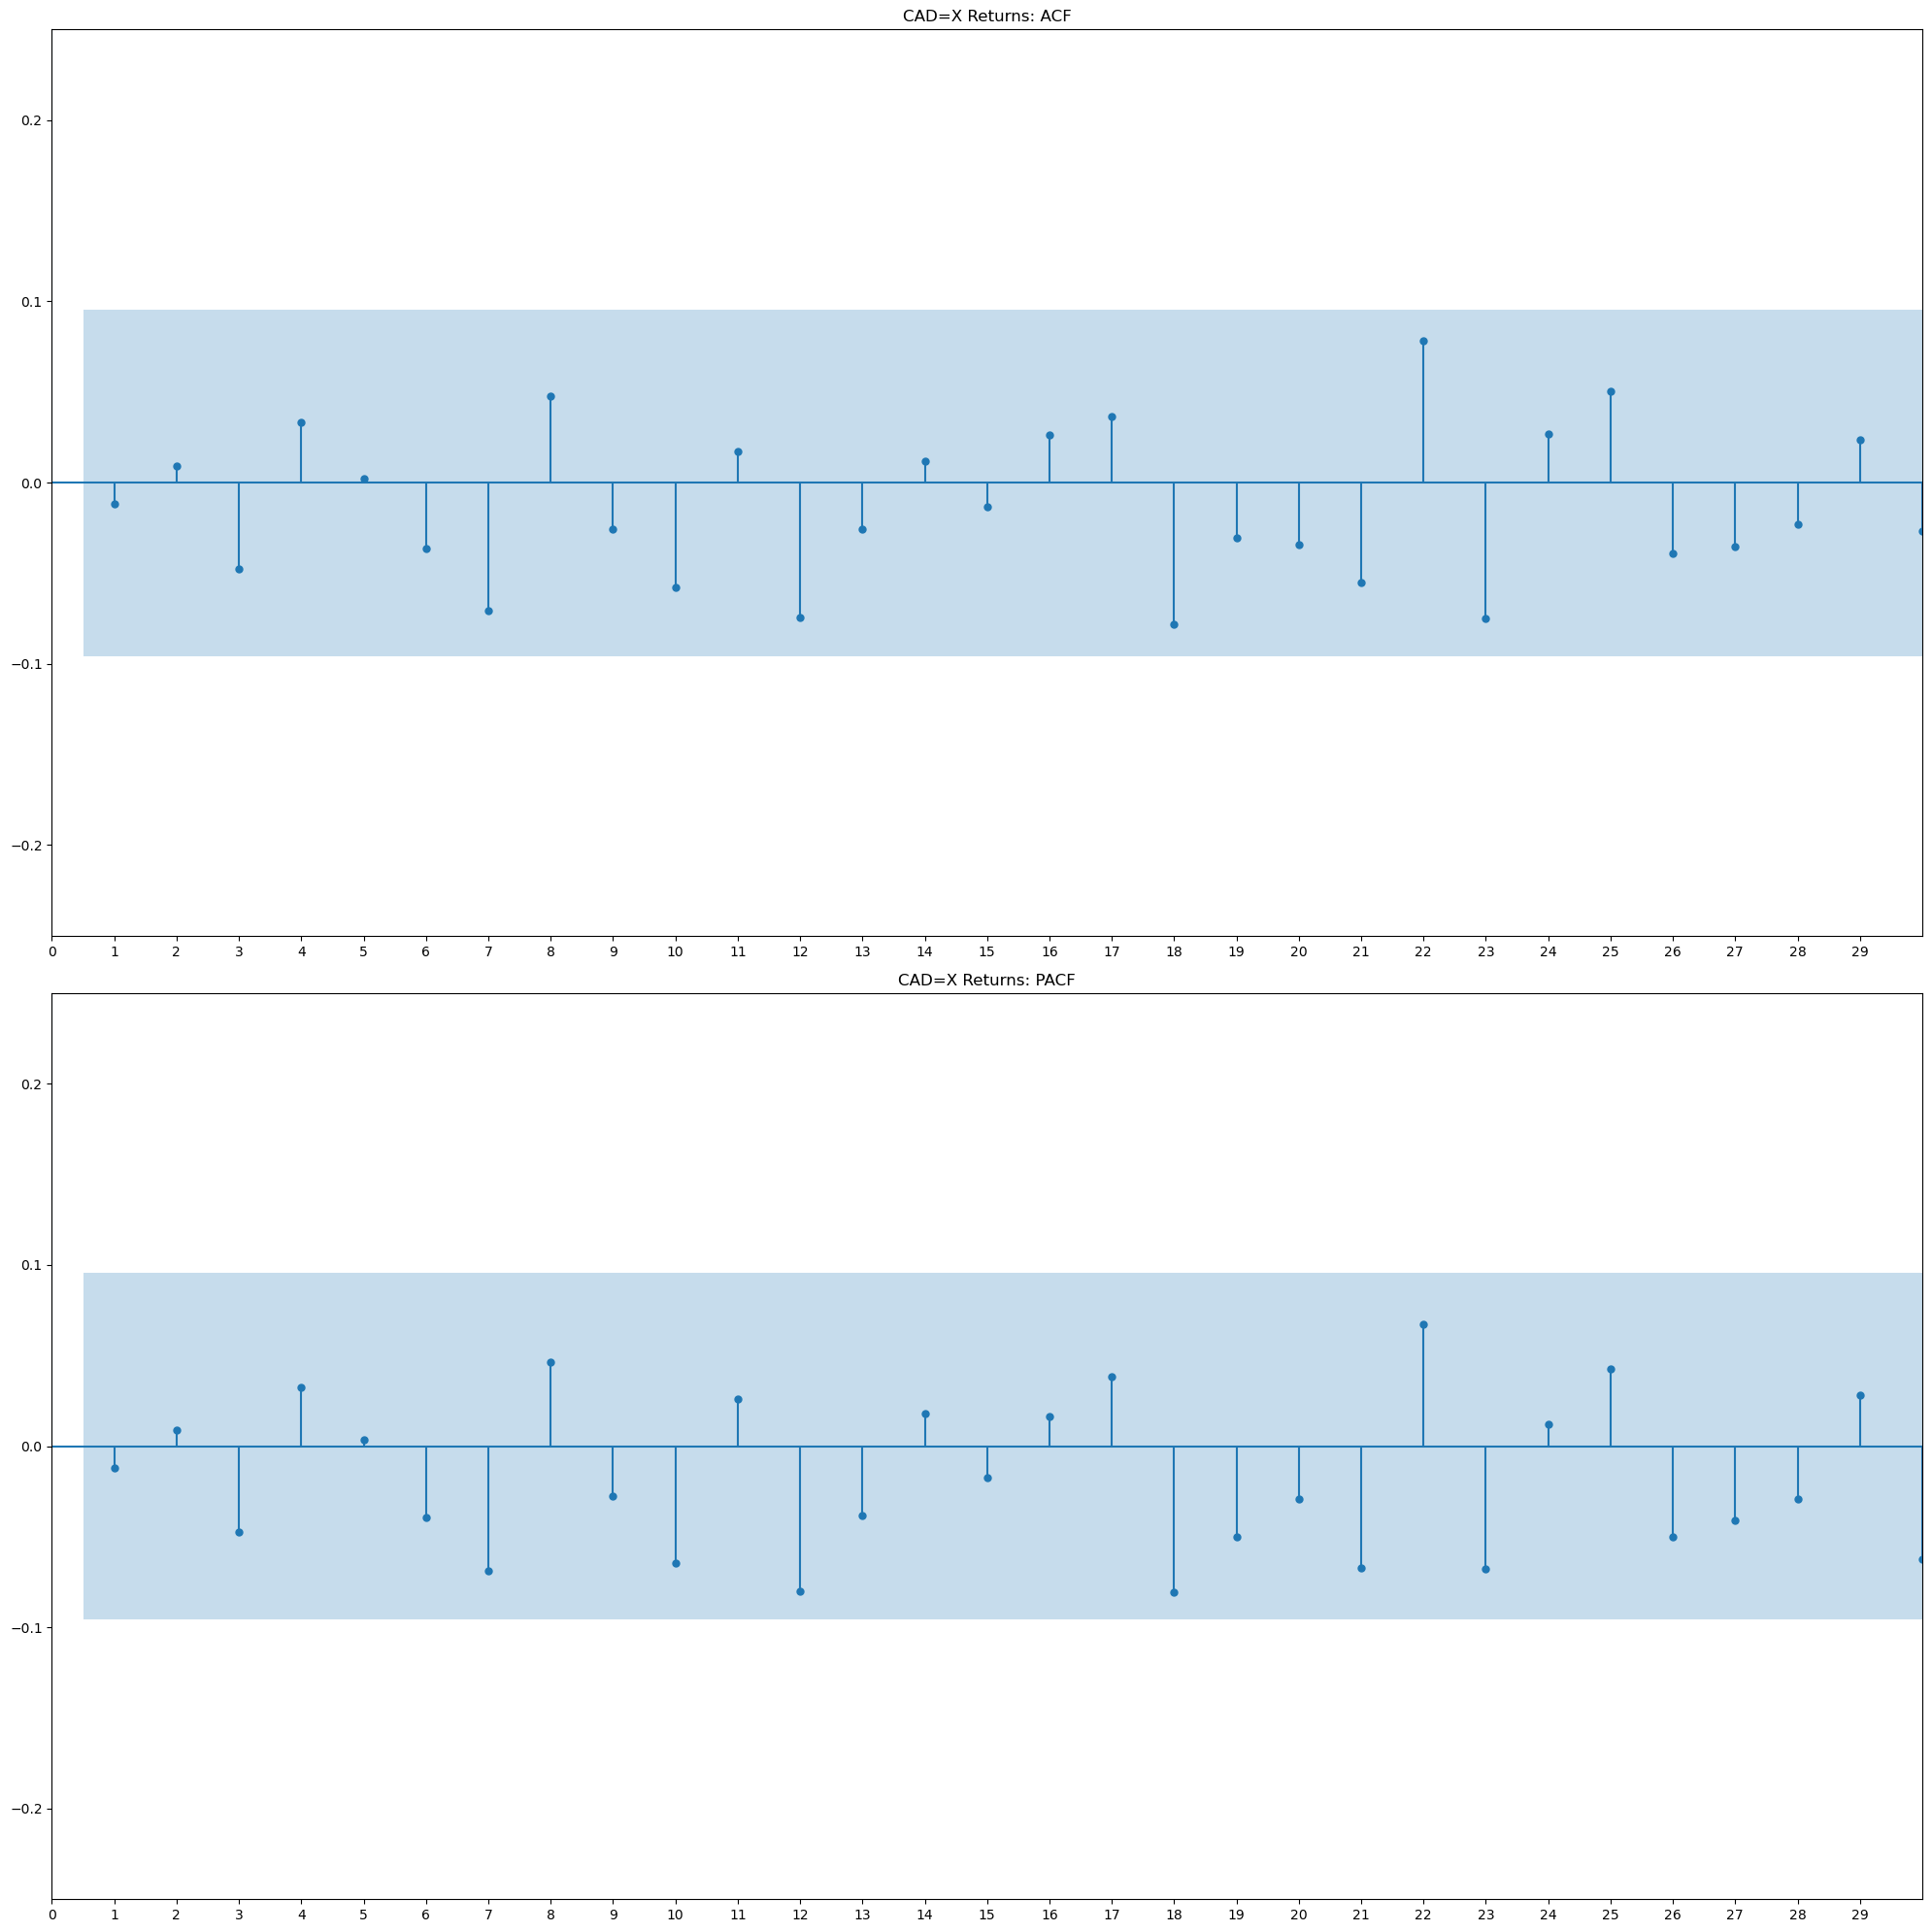

In [17]:
# Plot ACF and PACF for ticker in tickers
for ticker in tickers:
    fig, ax = plt.subplots(2, 1, figsize=(20,20))
    ymin, ymax = -0.25, 0.25

    title = f"{ticker} Returns"
    plot_acf(returns[ticker],
            lags=max_lags,
            bartlett_confint=False,
            ax=ax[0])
    ax[0].set_title(f"{title}: ACF")
    ax[0].set_xlim([0, max_lags])
    ax[0].set_ylim([ymin, ymax])
    ax[0].set_xticks(np.arange(0, max_lags, 1))

    plot_pacf(returns[ticker],
                lags=max_lags,
                method='ywmle',
                alpha=0.05,
                use_vlines=True,
                ax=ax[1])
    ax[1].set_title(f"{title}: PACF")
    ax[1].set_xlim([0, max_lags])
    ax[1].set_ylim([ymin, ymax])
    ax[1].set_xticks(np.arange(0, max_lags, 1)) 

    # save plot
    plt.savefig(f"../results/figures/ACF_PACF_{ticker}.png", dpi=300, bbox_inches="tight")
 
    plt.tight_layout() 
    plt.show()

In [18]:
# Ljung box test for autocorrelation
# H0: No autocorrelation up to lag k
# If p-value is small => reject null hypothesis of no autocorrelation
for ticker in tickers:
    lb_df = acorr_ljungbox(returns[ticker], lags=max_lags, return_df=True)
    lb_df['H0 Rejection'] = lb_df['lb_pvalue'] < 0.05

    lb_df.index.name = "Lag"

    print(f"Ljung-Box test results for {ticker}:")
    print(lb_df.head(10))

Ljung-Box test results for EURUSD=X:
       lb_stat  lb_pvalue  H0 Rejection
Lag                                    
1     0.898193   0.343267         False
2     6.619288   0.036529          True
3    10.809374   0.012803          True
4    18.773872   0.000871          True
5    22.424069   0.000435          True
6    22.616002   0.000936          True
7    33.285229   0.000023          True
8    33.434491   0.000051          True
9    33.489333   0.000110          True
10   42.105974   0.000007          True
Ljung-Box test results for BTD-USD:
      lb_stat  lb_pvalue  H0 Rejection
Lag                                   
1    0.039715   0.842039         False
2    2.557087   0.278443         False
3    3.356367   0.339874         False
4    3.358229   0.499760         False
5    3.383929   0.641019         False
6    3.386958   0.758944         False
7    3.751336   0.807932         False
8    4.850147   0.773466         False
9    5.395526   0.798557         False
10   7.838238   0.